# Rag From Scratch: Routing
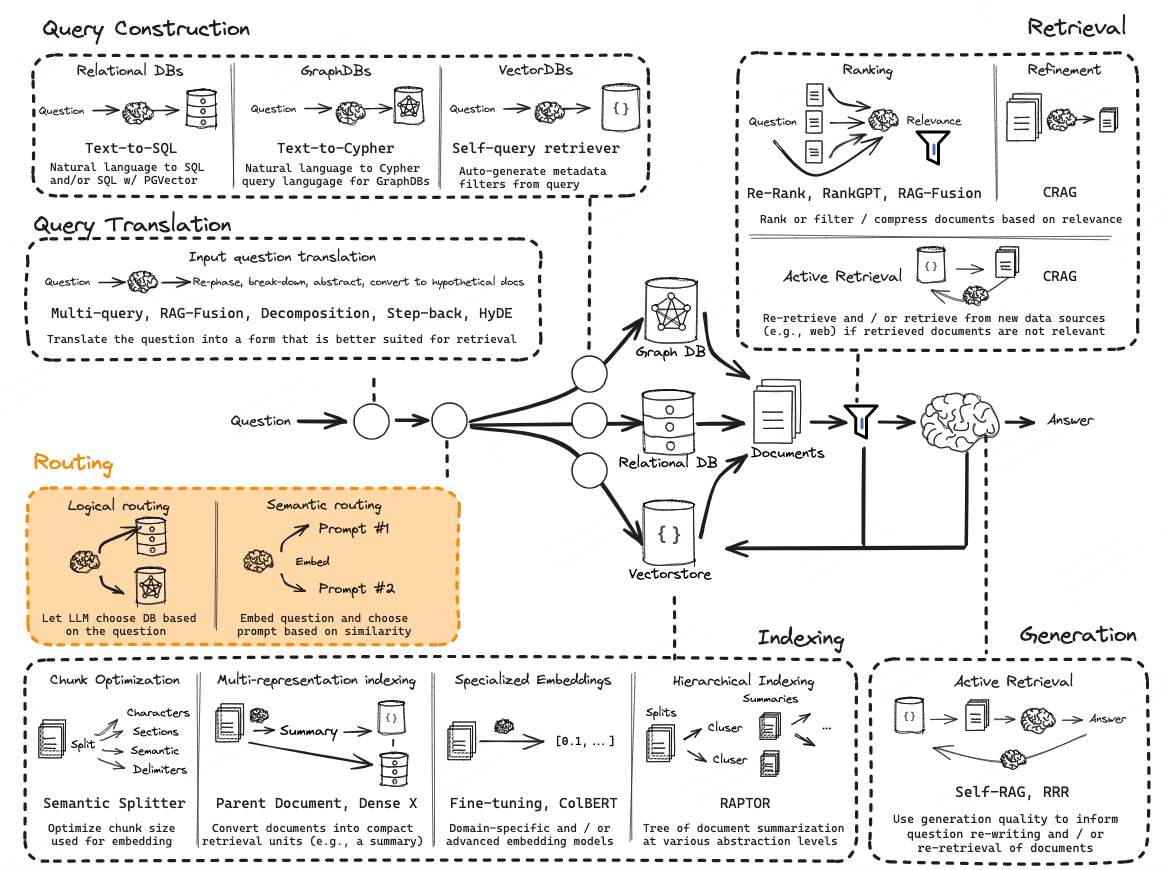

## Environment


In [ ]:
import os
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
# Set a User-Agent for polite web requests (helps with some sites)
os.environ["USER_AGENT"] = "rag-from-scratch/1.0 (+mailto:your-email@example.com)"

## Part 10: Logical and Semantic routing 

Use function-calling for classification.

Flow: 
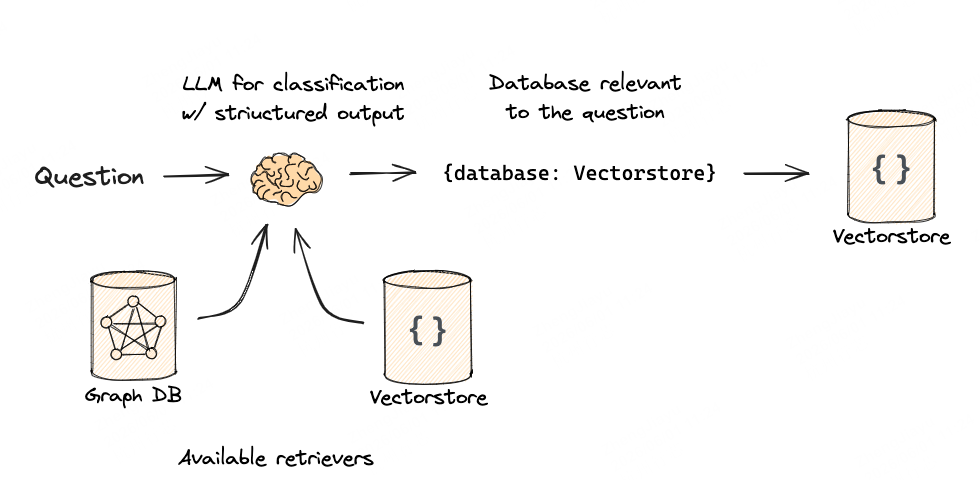

1. RAG 不只是“去查资料”，还要先判断这个问题应该被送去哪里处理。

2. 所谓“路由”，你可以把它理解成分诊台，先把不同类型的问题分到最合适的数据源、提示词或处理流程里。

3. 两种常见方法：一种是让模型按规则和理解来判断该走哪条路，另一种是靠向量相似度自动匹配最接近的路线。

4. 这样做的好处是，系统不用每次都走同一套检索流程，所以通常会更高效，也更容易拿到更合适的答案。

5. 如果你在做多知识库问答、企业内部搜索，或者想让 AI 根据问题类型自动切换策略，这一集就很值得看。
   
Docs:

https://python.langchain.com/docs/use_cases/query_analysis/techniques/routing#routing-to-multiple-indexes

In [ ]:
from typing import List, Dict, Any, Literal
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI

# 数据模型：约束 LLM 输出为固定 schema
class RoutingQuery(BaseModel):
    """Route a user query to the most relevant datasource."""

    # 只允许在给定的数据源集合中选择
    datasource: Literal["python_docs", "js_docs", "golang_docs"] = Field(
        ...,
        description="Given a user question choose which datasource would be most relevant for answering their question",
    )

# Model
chat_model = ChatOpenAI(
    model="qwen-plus",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
    temperature=0,
)
structured_llm = chat_model.with_structured_output(RoutingQuery)

# Prompt 
system = """You are an expert at routing a user question to the appropriate data source.

Based on the programming language the question is referring to, route it to the relevant data source."""

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question}"),
    ]
)

router = prompt | structured_llm


**Note**: we used function calling to produce structured output.
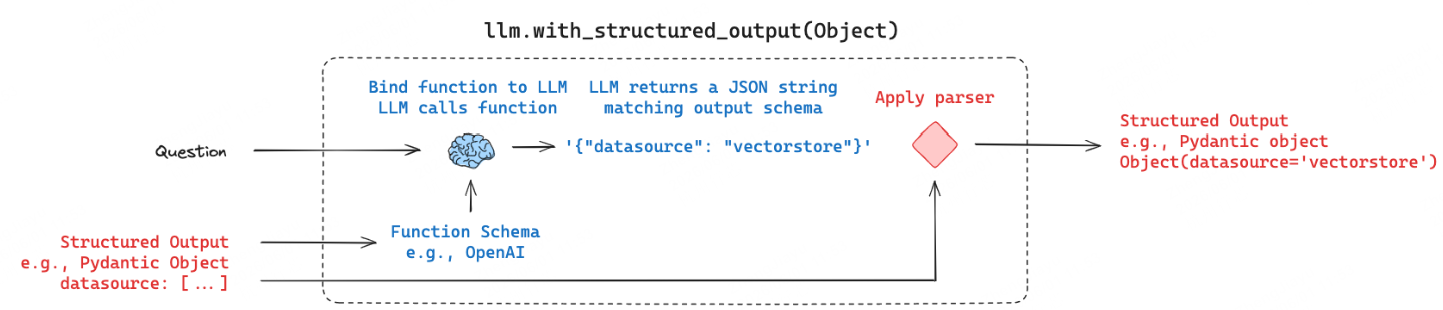

In [9]:
question = """Why doesn't the following code work:

from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages(["human", "speak in {language}"])
prompt.invoke("french")
"""

result = router.invoke({"question": question})

# test
result

RoutingQuery(datasource='python_docs')

In [8]:
result.datasource

'python_docs'

Once we have this, it is trivial to define a branch that uses `result.datasource`
> 这句话的意思是：“一旦我们拿到了这个分类结果（即 result.datasource 的值），接下来定义一个条件分支来使用它就非常简单了。”这在 LangChain 的路由（Routing）机制中，标志着流程从“语义意图识别”过渡到了“执行对应的处理逻辑” 。


In [10]:
def choose_route(result: RoutingQuery) -> str:
    if "python_docs" in result.datasource.lower():
        return "You should route this question to the Python documentation."
    elif "js_docs" in result.datasource.lower():
        return "You should route this question to the JavaScript documentation."
    elif "golang_docs" in result.datasource.lower():
        return "You should route this question to the Golang documentation."
    else:
        return "Unknown datasource."
    
from langchain_core.runnables import RunnableLambda

full_chain = router | RunnableLambda(choose_route)

In [11]:
full_chain.invoke({"question": question})

'You should route this question to the Python documentation.'

### Semantic routing

Flow:

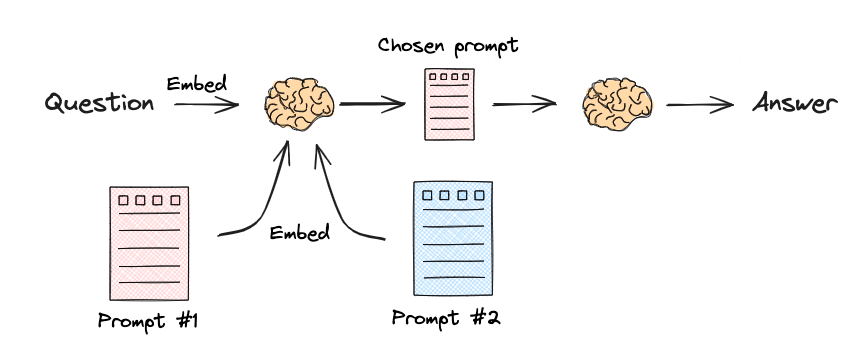


In [13]:
from langchain_community.utils.math import cosine_similarity
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

# Two prompts
physics_template = """你是一位非常聪明的物理学教授。
你擅长以简洁且易懂的方式回答物理问题。
如果你不知道某个问题的答案，你会诚实地承认不知道。

下面是一个问题：
{query}"""

math_template = """你是一位优秀的数学家，擅长回答数学问题。
你之所以优秀，是因为你能够将难题拆解为若干子问题，逐一解答这些子问题，然后将结果组合起来回答更广泛的问题。

下面是一个问题：
{query}"""

# Embed prompts
embd_model = OpenAIEmbeddings(
    model="text-embedding-v3",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
    chunk_size=10,
    check_embedding_ctx_length=False,
)
prompt_templates = [physics_template, math_template]
prompt_embeddings = embd_model.embed_documents(prompt_templates)

#route question to prompt
def prompt_router(input):
    # Embed the input question
    query_embedding = embd_model.embed_query(input["query"])

    # Compute cosine similarity between input and each prompt
    similarity = cosine_similarity([query_embedding], prompt_embeddings)[0]
    most_similar = prompt_templates[similarity.argmax()]

    #chosen prompt
    print("Using MATH" if most_similar == math_template else "Using PHYSICS")
    return PromptTemplate.from_template(most_similar)

chain = (
    {"query": RunnablePassthrough()}
    | RunnableLambda(prompt_router)
    | chat_model
    | StrOutputParser()
)

print(chain.invoke("What's a black hole"))

C:\Users\zhengjiayu\AppData\Local\Temp\ipykernel_21820\3307414710.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utils.math import cosine_similarity


C:\Users\zhengjiayu\AppData\Local\Temp\ipykernel_21820\3307414710.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utils.math import cosine_similarity


Using PHYSICS
A black hole is a region of spacetime where gravity is so strong that *nothing—not even light—can escape* from it once it crosses a boundary called the **event horizon**.

It forms when a massive star collapses under its own gravity at the end of its life, compressing its mass into an extremely small volume. At the center lies a **singularity**, where density becomes infinite and our current laws of physics break down.

Key ideas (in simple terms):  
- **Event horizon**: The “point of no return”—not a physical surface, but a one-way membrane in space.  
- **Mass, spin, and charge**: According to the “no-hair theorem”, black holes are fully described by just these three properties.  
- **Not cosmic vacuums**: They don’t “suck” things in any more than a star of the same mass would—they just warp spacetime intensely nearby.

Fun fact: We’ve now *imaged* black holes directly—the shadow of M87* (2019) and Sagittarius A* (2022)—confirming Einstein’s predictions.

Let me know if

# Rag From Scratch: Query Construction

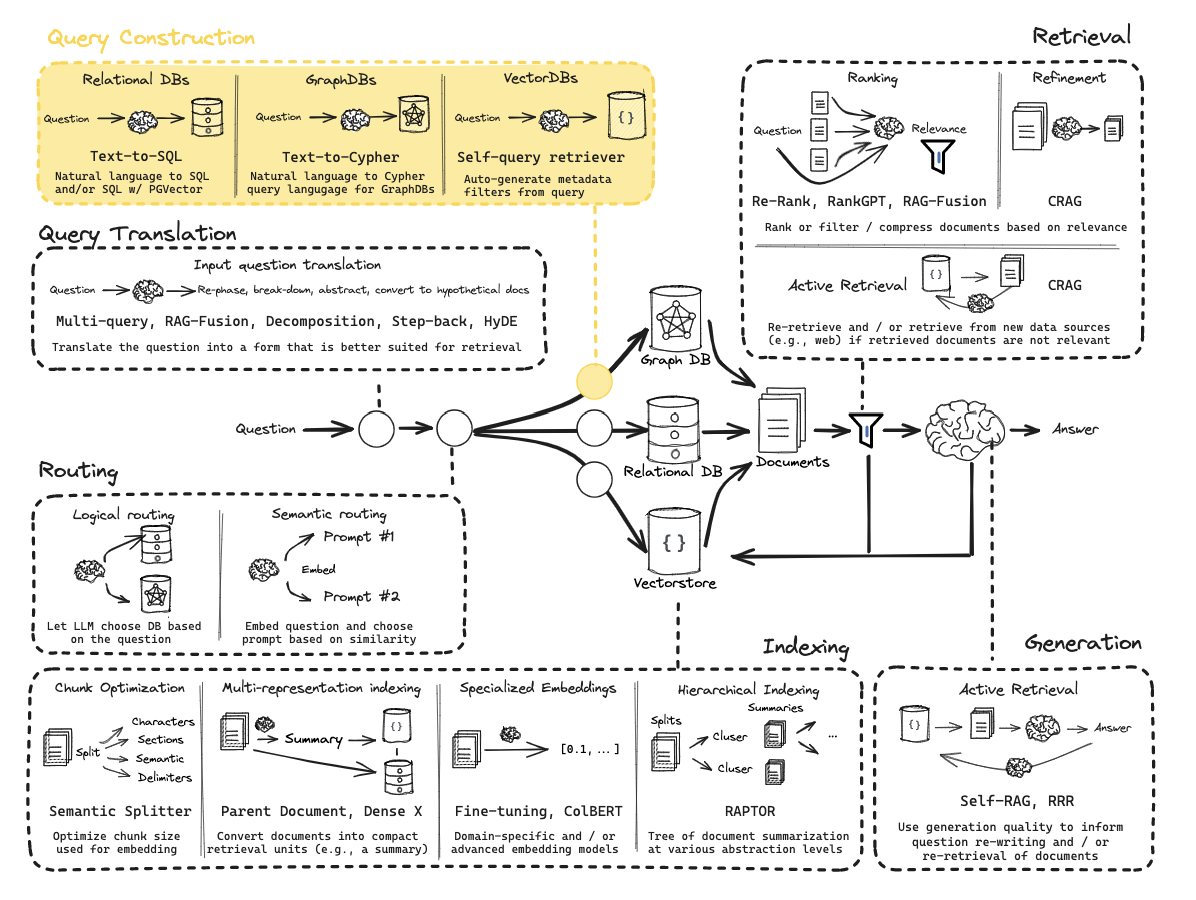

For graph and SQL, see helpful resources:

https://blog.langchain.dev/query-construction/

https://blog.langchain.dev/enhancing-rag-based-applications-accuracy-by-constructing-and-leveraging-knowledge-graphs/

## Part 11: Query structuring for metadata filters

Flow:
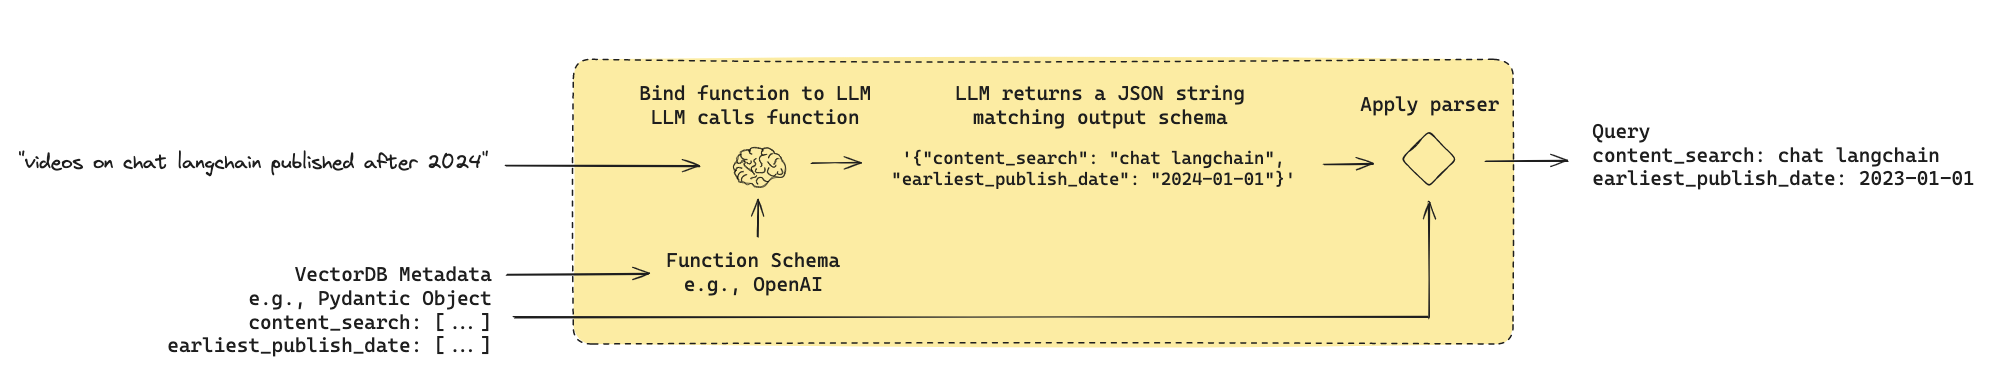

可以把这个过程总结为一句话：
用大模型（LLM）的“大脑”去把人类模糊的自然语言，**翻译成数据库能看懂的“严谨条件”**，然后再让数据库去执行搜索（Retrieve）

In [22]:
import pytube.innertube

# 将 pytube 默认的客户端强制改为 WEB
pytube.innertube._default_clients["ANDROID"] = pytube.innertube._default_clients["WEB"]
pytube.innertube._default_clients["ANDROID_MUSIC"] = pytube.innertube._default_clients["WEB"]
from langchain_community.document_loaders import YoutubeLoader

docs = YoutubeLoader.from_youtube_url(
    "https://www.youtube.com/watch?v=pbAd8O1Lvm4", add_video_info=True
).load()

docs[0].metadata
# docs[0].page_content

{'source': 'pbAd8O1Lvm4',
 'title': 'Self-reflective RAG with LangGraph: Self-RAG and CRAG',
 'description': 'Self-reflection can greatly enhance RAG, enabling correction of poor quality retrieval or generations. Several recent RAG papers focus on this theme, but implementing the ideas can be tricky. Here, we show that LangGraph can be easily used for "flow engineering" of self-reflective RAG pipelines. We provide cookbooks for implementing ideas from two interesting papers, Self-RAG and C-RAG.\n\nCode:\nhttps://github.com/langchain-ai/langgraph/tree/main/examples/rag',
 'view_count': 38307,
 'thumbnail_url': 'https://i.ytimg.com/vi/pbAd8O1Lvm4/maxresdefault.jpg',
 'publish_date': '2024-02-07 00:00:00',
 'length': 1058,
 'author': 'LangChain'}

In [40]:
import datetime
from typing import Literal, Optional, Tuple
from pydantic import BaseModel, Field

class TutorialSearch(BaseModel):
    """Search over a database of tutorial videos about a software library."""

    content_search: str = Field(
        ...,
        description="Similarity search query applied to video transcripts.",
    )
    title_search: str = Field(
        ...,
        description=(
            "Alternate version of the content search query to apply to video titles. "
            "Should be succinct and only include key words that could be in a video "
            "title."
        ),
    )
    min_view_count: Optional[int] = Field(
        None,
        description="Minimum view count filter, inclusive. Only use if explicitly specified.",
    )
    max_view_count: Optional[int] = Field(
        None,
        description="Maximum view count filter, exclusive. Only use if explicitly specified.",
    )
    earliest_publish_date: Optional[datetime.date] = Field(
        None,
        description="Earliest publish date filter, inclusive. Only use if explicitly specified.",
    )
    latest_publish_date: Optional[datetime.date] = Field(
        None,
        description="Latest publish date filter, exclusive. Only use if explicitly specified.",
    )
    min_length_sec: Optional[int] = Field(
        None,
        description="Minimum video length in seconds, inclusive. Only use if explicitly specified.",
    )
    max_length_sec: Optional[int] = Field(
        None,
        description="Maximum video length in seconds, exclusive. Only use if explicitly specified.",
    )

    def pretty_print(self) -> None:
        model_fields = type(self).model_fields
        for field in model_fields:
            field_default = model_fields[field].default
            if getattr(self, field) is not None and getattr(self, field) != field_default:
                print(f"{field}: {getattr(self, field)}")


Now, we prompt the LLM to produce queries.

In [44]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

system = """You are an expert at converting user questions into database queries. \
You have access to a database of tutorial videos about a software library for building LLM-powered applications. \
Given a question, return a database query optimized to retrieve the most relevant results.

Only set optional filters (like view counts, publish dates, or length) if the user explicitly mentions them in their question. If the user does not mention a filter, leave it null. Do not make up numeric ranges or dates.

If there are acronyms or words you are not familiar with, do not try to rephrase them."""
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question}"),
    ]
)

structured_llm = chat_model.with_structured_output(TutorialSearch)
query_analyzer = prompt | structured_llm

In [46]:
query_analyzer.invoke({"question": "rag from scratch"}).pretty_print()

content_search: rag from scratch
title_search: rag from scratch


In [47]:
query_analyzer.invoke(
    {"question": "videos on chat langchain published in 2023"}
).pretty_print()

content_search: chat langchain
title_search: 
earliest_publish_date: 2023-01-01
latest_publish_date: 2023-12-31


In [48]:
query_analyzer.invoke(
    {"question": "videos that are focused on the topic of chat langchain that are published before 2024"}
).pretty_print()

content_search: chat langchain
title_search: chat langchain
earliest_publish_date: 2024-01-01


In [49]:
query_analyzer.invoke(
    {
        "question": "how to use multi-modal models in an agent, only videos under 5 minutes"
    }
).pretty_print()

content_search: multi-modal models agent
title_search: multi-modal
max_length_sec: 300
